In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, argrelextrema
from sklearn.neighbors import NearestNeighbors

# --- Helper Functions for Parameter Estimation ---

def average_mutual_information(x, max_lag=100, bins=64):
    """
    Calculate the average mutual information for a time series.
    Finds the first local minimum to suggest an optimal delay `tau`.
    """
    x = np.asarray(x)
    ami_values = np.zeros(max_lag)
    for lag in range(1, max_lag + 1):
        if lag >= len(x):
            ami_values[lag - 1] = np.nan
            continue
        x1 = x[:-lag]
        x2 = x[lag:]
        
        hist_2d, _, _ = np.histogram2d(x1, x2, bins=bins)
        pxy = hist_2d / np.sum(hist_2d)
        px = np.sum(pxy, axis=1)
        py = np.sum(pxy, axis=0)
        px_py = np.outer(px, py)
        nzs = pxy > 0
        mi = np.sum(pxy[nzs] * np.log(pxy[nzs] / px_py[nzs]))
        ami_values[lag - 1] = mi
        
    return ami_values

def find_optimal_delay(time_series):
    ami = average_mutual_information(time_series)
    local_min_indices = argrelextrema(ami, np.less)[0]
    if len(local_min_indices) > 0:
        return local_min_indices[0] + 1
    try:
        return np.where(ami < ami[0] / np.e)[0][0] + 1
    except IndexError:
        return 1

def delay_embedding_aligned(x, m, tau):
    x = np.asarray(x)
    n_vectors = len(x) - (m + 1) * tau + 1
    if n_vectors <= 0:
        return np.empty((0, m)), np.empty((0, m + 1))
    Y_m = np.array([x[i:i + m * tau:tau] for i in range(n_vectors)])
    Y_mp1 = np.array([x[i:i + (m + 1) * tau:tau] for i in range(n_vectors)])
    return Y_m, Y_mp1

def false_nearest_neighbors_fraction(x, tau, max_dim=10, rtol=10.0, atol=2.0):
    fnn_fractions = []
    x_std = np.std(x)
    for m in range(1, max_dim + 1):
        if len(x) <= (m + 1) * tau:
            fnn_fractions.append(np.nan)
            continue

        Y_m, Y_mp1 = delay_embedding_aligned(x, m, tau)
        if Y_m.shape[0] == 0:
            fnn_fractions.append(np.nan)
            continue
            
        nbrs = NearestNeighbors(n_neighbors=2, algorithm='auto').fit(Y_m)
        distances, indices = nbrs.kneighbors(Y_m)
        dist_m = distances[:, 1]
        neighbors_idx = indices[:, 1]
        dist_mp1 = np.linalg.norm(Y_mp1 - Y_mp1[neighbors_idx], axis=1)
        with np.errstate(divide='ignore', invalid='ignore'):
            cond1 = dist_mp1 / dist_m > rtol
            cond2 = dist_mp1 / x_std > atol
        false_neighbors = np.logical_or(cond1, cond2)
        valid_indices = dist_m > 0
        fnn_fraction = np.sum(false_neighbors[valid_indices]) / np.sum(valid_indices) if np.sum(valid_indices) > 0 else 1.0
        fnn_fractions.append(fnn_fraction)
    return np.array(fnn_fractions)

def find_optimal_dimension(time_series, tau):
    fnn_fracs = false_nearest_neighbors_fraction(time_series, tau=tau)
    try:
        return np.where(fnn_fracs < 0.1)[0][0] + 1
    except IndexError:
        return np.argmin(fnn_fracs) + 1

# --- Main Lyapunov Exponent Function ---

def lyapunov_exponent(time_series, m, J, fit_start_idx, fit_end_idx, fs=1, max_iter=500):
    N = len(time_series)
    M = N - (m - 1) * J
    if M <= 10:
        return np.nan, np.array([]), np.array([])
    X = np.array([time_series[i:i + (m - 1) * J + 1:J] for i in range(M)])
    frequencies, power_spectrum = welch(time_series, fs, nperseg=min(N, 256))
    if np.sum(power_spectrum) > 0:
        mean_frequency = np.sum(frequencies * power_spectrum) / np.sum(power_spectrum)
        mean_period = int(1 / mean_frequency) if mean_frequency > 1e-6 else N // 2
    else:
        mean_period = N // 10
    neighbors = np.zeros(M, dtype=int)
    for i in range(M):
        dists = np.linalg.norm(X - X[i], axis=1)
        dists[max(0, i - mean_period):min(M, i + mean_period + 1)] = np.inf
        neighbors[i] = np.argmin(dists)
    log_divergence = []
    for k in range(max_iter):
        d_k = 0
        count = 0
        for i in range(M):
            j = neighbors[i]
            if i + k < M and j + k < M:
                dist = np.linalg.norm(X[i + k] - X[j + k])
                if dist > 1e-12:
                    d_k += np.log(dist)
                    count += 1
        if count > 0:
            log_divergence.append(d_k / count)
        else:
            break
    t = np.arange(len(log_divergence)) * (1.0 / fs)
    start_index = fit_start_idx
    end_index = min(fit_end_idx, len(t))
    if end_index > start_index + 2:
        coeffs = np.polyfit(t[start_index:end_index], log_divergence[start_index:end_index], 1)
        lambda_1 = coeffs[0]
    else:
        lambda_1 = np.nan
    return lambda_1, t, np.array(log_divergence)

# --- Main Execution Block ---

if __name__ == '__main__':
    stocks = ['AAPL', 'ADBE', 'AMAT', 'AMZN', 'CSCO', 'GOOGL', 'INTC', 'INTU',
              'KLAC', 'LRCX', 'META', 'MSFT', 'MU', 'NFLX', 'NVDA', 'QCOM', 'TSLA', 'TXN']
    data_dir = 'clean_data'
    plot_dir = 'geminiplots'
    results = []

    if not os.path.exists(plot_dir):
        os.makedirs(plot_dir)
        print(f"Created directory: {plot_dir}")

    if not os.path.exists(data_dir):
        print(f"Error: Directory '{data_dir}' not found.")
    else:
        for stock in stocks:
            file_path = os.path.join(data_dir, f"{stock}_clean.csv")
            if not os.path.exists(file_path):
                print(f"\n--- {stock}: File not found. Skipping. ---")
                continue

            print(f"\n--- Analyzing {stock} ---")

            try:
                df = pd.read_csv(file_path)
                time_series = df['Log_Return_Clean'].values
                fs = 1

                # Optimal parameters
                J = find_optimal_delay(time_series)
                m_opt = find_optimal_dimension(time_series, tau=J)
                print(f"Optimal Delay (J): {J}, Optimal Dimension (m): {m_opt}")

                fit_start_day, fit_end_day = 0, 40
                dims_to_test = [m_opt, m_opt + 2, m_opt + 4]

                for m in dims_to_test:
                    lambda_1, t, log_d = lyapunov_exponent(time_series, m=m, J=J,
                                                           fs=fs, fit_start_idx=fit_start_day,
                                                           fit_end_idx=fit_end_day)

                    if np.isnan(lambda_1):
                        print(f"  m={m}: Failed to calculate Lyapunov exponent.")
                        results.append({'Stock': stock, 'm': m, 'J': J, 'Lyapunov Exp.': 'Failed'})
                    else:
                        print(f"  m={m}: λ₁ = {lambda_1:.6f}")
                        results.append({'Stock': stock, 'm': m, 'J': J, 'Lyapunov Exp.': f"{lambda_1:.6f}"})

                        # Plot
                        plt.figure(figsize=(10, 6))
                        plt.plot(t, log_d, label='<ln(divergence)>')
                        start_idx_plot = fit_start_day
                        end_idx_plot = min(fit_end_day, len(t))
                        if end_idx_plot > start_idx_plot + 2:
                            fit_coeffs = np.polyfit(t[start_idx_plot:end_idx_plot],
                                                    log_d[start_idx_plot:end_idx_plot], 1)
                            fit_line = np.poly1d(fit_coeffs)
                            plt.plot(t[start_idx_plot:end_idx_plot],
                                     fit_line(t[start_idx_plot:end_idx_plot]), 'r--',
                                     label=f'Linear fit (λ₁={fit_coeffs[0]:.6f})')

                        plt.title(f'{stock} (m={m}, J={J})')
                        plt.xlabel('Time (days)')
                        plt.ylabel('<ln(divergence)>')
                        plt.legend()
                        plt.grid(True)
                        save_path = os.path.join(plot_dir, f"{stock}_m{m}_lyapunov.png")
                        plt.savefig(save_path)
                        plt.close()
                        print(f"    Saved plot: {save_path}")

            except Exception as e:
                print(f"Error processing {stock}: {e}")
                results.append({'Stock': stock, 'm': '-', 'J': '-', 'Lyapunov Exp.': 'Error'})

        # Save results
        results_df = pd.DataFrame(results)
        print("\n--- Summary of Results ---")
        print(results_df.to_string(index=False))

        results_df_renamed = results_df.rename(columns={
            'Stock': 'stock_symbol',
            'm': 'M',
            'J': 'Delay',
            'Lyapunov Exp.': 'Lyapunov exponent'
        })
        csv_path = 'lyapunov_results3.csv'
        results_df_renamed.to_csv(csv_path, index=False)
        print(f"\nResults saved to {csv_path}")



--- Analyzing AAPL ---
Optimal Delay (J): 6, Optimal Dimension (m): 5
  m=5: λ₁ = 0.019143
    Saved plot: geminiplots/AAPL_m5_lyapunov.png
  m=7: λ₁ = 0.014844
    Saved plot: geminiplots/AAPL_m7_lyapunov.png
  m=9: λ₁ = 0.011599
    Saved plot: geminiplots/AAPL_m9_lyapunov.png

--- Analyzing ADBE ---
Optimal Delay (J): 7, Optimal Dimension (m): 5
  m=5: λ₁ = 0.015600
    Saved plot: geminiplots/ADBE_m5_lyapunov.png
  m=7: λ₁ = 0.011760
    Saved plot: geminiplots/ADBE_m7_lyapunov.png
  m=9: λ₁ = 0.008874
    Saved plot: geminiplots/ADBE_m9_lyapunov.png

--- Analyzing AMAT ---
Optimal Delay (J): 6, Optimal Dimension (m): 6
  m=6: λ₁ = 0.017554
    Saved plot: geminiplots/AMAT_m6_lyapunov.png
  m=8: λ₁ = 0.013197
    Saved plot: geminiplots/AMAT_m8_lyapunov.png
  m=10: λ₁ = 0.010659
    Saved plot: geminiplots/AMAT_m10_lyapunov.png

--- Analyzing AMZN ---
Optimal Delay (J): 5, Optimal Dimension (m): 7
  m=7: λ₁ = 0.017792
    Saved plot: geminiplots/AMZN_m7_lyapunov.png
  m=9: λ₁ = 0.

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema
from scipy.spatial.distance import pdist
from scipy.stats import linregress

# --- Helper Functions ---

def average_mutual_information(x, max_lag=100, bins=64):
    x = np.asarray(x)
    ami_values = np.zeros(max_lag)
    for lag in range(1, max_lag + 1):
        if lag >= len(x):
            ami_values[lag - 1] = np.nan
            continue
        x1, x2 = x[:-lag], x[lag:]
        hist_2d, _, _ = np.histogram2d(x1, x2, bins=bins)
        pxy = hist_2d / np.sum(hist_2d)
        px, py = np.sum(pxy, axis=1), np.sum(pxy, axis=0)
        px_py = np.outer(px, py)
        with np.errstate(divide='ignore', invalid='ignore'):
            nzs = pxy > 0
            ami_values[lag - 1] = np.sum(pxy[nzs] * np.log(pxy[nzs] / px_py[nzs]))
    return ami_values

def find_optimal_delay(time_series):
    ami = average_mutual_information(time_series)
    local_min_indices = argrelextrema(ami, np.less)[0]
    if len(local_min_indices) > 0:
        return local_min_indices[0] + 1
    try:
        return np.where(ami < ami[0] / np.e)[0][0] + 1
    except IndexError:
        return 1

def grassberger_procaccia(data, radii):
    n_points = data.shape[0]
    distances = pdist(data)
    correlation_sum = np.zeros(len(radii))
    n_pairs = n_points * (n_points - 1) / 2.0
    for i, r in enumerate(radii):
        correlation_sum[i] = np.sum(distances < r) / n_pairs if n_pairs > 0 else 0
    return correlation_sum

# --- Main Execution for Multiple Stocks ---

stocks = ['AAPL', 'ADBE', 'AMAT', 'AMZN', 'CSCO', 'GOOGL', 'INTC', 'INTU',
          'KLAC', 'LRCX', 'META', 'MSFT', 'MU', 'NFLX', 'NVDA', 'QCOM', 'TSLA', 'TXN']

data_dir = 'clean_data'
plot_dir = 'correlation_plot'
os.makedirs(plot_dir, exist_ok=True)

selected_m = [5, 7, 9]  # Embedding dimensions to summarize
summary_results = []

for stock in stocks:
    file_path = os.path.join(data_dir, f"{stock}_clean.csv")
    
    if not os.path.exists(file_path):
        print(f"Data for {stock} not found, skipping.")
        continue
    
    try:
        df = pd.read_csv(file_path)
        time_series = df['Log_Return_Clean'].values
        if len(time_series) < 10:
            print(f"Not enough data for {stock}, skipping.")
            continue
        
        print(f"\nProcessing {stock}...")
        J = find_optimal_delay(time_series)
        print(f"Optimal delay J={J}")
        
        m_values = range(1, 11)
        d2_estimates = {}
        std_dev = np.std(time_series)
        if std_dev < 1e-9:
            print(f"{stock} time series has near-zero variance, skipping.")
            continue
        radii = np.logspace(-3, 1, 100) * std_dev
        FIT_LOG_C_START, FIT_LOG_C_END = -12.0, -4.0
        
        for m in m_values:
            n_points_embedded = len(time_series) - (m - 1) * J
            if n_points_embedded < 100:
                print(f"  Not enough points for m={m}, stopping embedding.")
                break
            embedded_space = np.array([time_series[i:i + m*J:J] for i in range(n_points_embedded)])
            correlation_sum = grassberger_procaccia(embedded_space, radii)
            valid_indices = np.where(correlation_sum > 0)
            if len(valid_indices[0]) < 2:
                slope = np.nan
            else:
                log_r = np.log(radii[valid_indices])
                log_C_r = np.log(correlation_sum[valid_indices])
                scaling_region_indices = np.where((log_C_r > FIT_LOG_C_START) & (log_C_r < FIT_LOG_C_END))
                if len(scaling_region_indices[0]) < 3:
                    slope = np.nan
                else:
                    fit_x = log_r[scaling_region_indices]
                    fit_y = log_C_r[scaling_region_indices]
                    slope, intercept, _, _, _ = linregress(fit_x, fit_y)
            d2_estimates[m] = slope
            
            # Save individual log-log plot
            plt.figure(figsize=(8,6))
            plt.plot(np.log(radii[valid_indices]), np.log(correlation_sum[valid_indices]), 'b.', markersize=4)
            if not np.isnan(slope):
                plt.plot(fit_x, slope*fit_x + intercept, 'r-', linewidth=2)
            plt.title(f'{stock} log-log C(r) vs r (m={m}, J={J})')
            plt.xlabel('log(r)')
            plt.ylabel('log(C(r))')
            plt.grid(True)
            plt.savefig(os.path.join(plot_dir, f"{stock}_loglog_m{m}.png"))
            plt.close()
        
        # Save D2 vs m plot
        plt.figure(figsize=(10,6))
        m_points = np.arange(1, len(d2_estimates)+1)
        plt.plot(m_points, list(d2_estimates.values()), 'o-', label=f'Estimated D2 for {stock}')
        plt.plot(m_points, m_points, 'r--', label='Theoretical D2=m (Random Noise)')
        plt.title(f'Correlation Dimension D2 vs m for {stock} (J={J})')
        plt.xlabel('Embedding Dimension m')
        plt.ylabel('Estimated D2')
        plt.xticks(m_points)
        plt.grid(True)
        plt.legend()
        plt.savefig(os.path.join(plot_dir, f"{stock}_D2_vs_m.png"))
        plt.close()
        
        # Collect summary for selected m
        summary_results.append({
            'Stock': stock,
            **{f'D2_m{m}': d2_estimates.get(m, np.nan) for m in selected_m}
        })
        
    except Exception as e:
        print(f"Error processing {stock}: {e}")

# --- Save summary table as CSV ---
summary_df = pd.DataFrame(summary_results)
summary_csv_path = os.path.join(plot_dir, 'correlation_dimension_summary.csv')
summary_df.to_csv(summary_csv_path, index=False)
print(f"\nSaved summary table to {summary_csv_path}")
print(summary_df)



Processing AAPL...
Optimal delay J=6

Processing ADBE...
Optimal delay J=7

Processing AMAT...
Optimal delay J=6

Processing AMZN...
Optimal delay J=5

Processing CSCO...
Optimal delay J=5

Processing GOOGL...
Optimal delay J=8

Processing INTC...
Optimal delay J=6

Processing INTU...
Optimal delay J=5

Processing KLAC...
Optimal delay J=7

Processing LRCX...
Optimal delay J=6

Processing META...
Optimal delay J=5

Processing MSFT...
Optimal delay J=6

Processing MU...
Optimal delay J=7

Processing NFLX...
Optimal delay J=6

Processing NVDA...
Optimal delay J=6

Processing QCOM...
Optimal delay J=6

Processing TSLA...
Optimal delay J=6

Processing TXN...
Optimal delay J=5

Saved summary table to correlation_plot/correlation_dimension_summary.csv
    Stock     D2_m5     D2_m7     D2_m9
0    AAPL  4.499372  5.027083  4.975800
1    ADBE  4.635790  5.183681  5.339853
2    AMAT  4.502241  5.187305  5.251015
3    AMZN  4.576267  5.255470  5.036460
4    CSCO  4.352755  4.853028  5.110003
5  

META: Optimal Delay (J) = 5, Estimated True Dimension (m_opt) = 5
  m=1: LLE = 0.031136
  m=2: LLE = 0.023172
  m=3: LLE = 0.022030
  m=4: LLE = 0.021511
  m=5: LLE = 0.020860
  m=6: LLE = 0.019870
  m=7: LLE = 0.018287
  m=8: LLE = 0.016213


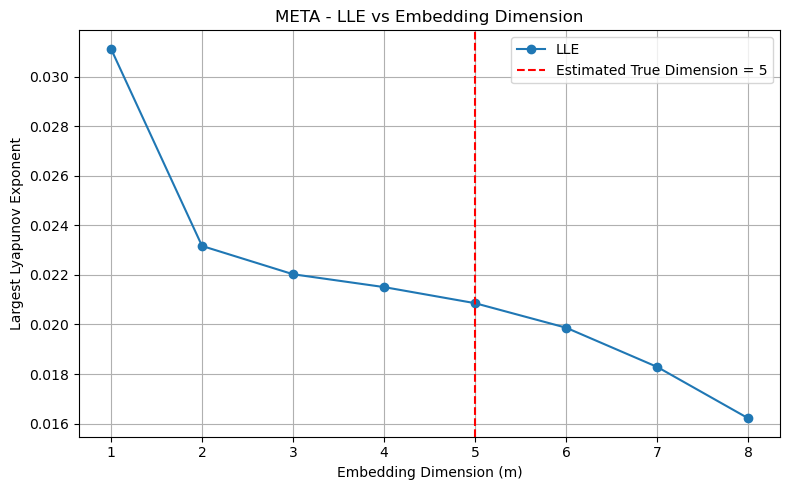

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, argrelextrema
from sklearn.neighbors import NearestNeighbors

# --- Helper Functions for Parameter Estimation ---

def average_mutual_information(x, max_lag=100, bins=64):
    x = np.asarray(x)
    ami_values = np.zeros(max_lag)
    for lag in range(1, max_lag + 1):
        if lag >= len(x):
            ami_values[lag - 1] = np.nan
            continue
        x1 = x[:-lag]
        x2 = x[lag:]
        hist_2d, _, _ = np.histogram2d(x1, x2, bins=bins)
        pxy = hist_2d / np.sum(hist_2d)
        px = np.sum(pxy, axis=1)
        py = np.sum(pxy, axis=0)
        px_py = np.outer(px, py)
        nzs = pxy > 0
        mi = np.sum(pxy[nzs] * np.log(pxy[nzs] / px_py[nzs]))
        ami_values[lag - 1] = mi
    return ami_values

def find_optimal_delay(time_series):
    ami = average_mutual_information(time_series)
    local_min_indices = argrelextrema(ami, np.less)[0]
    if len(local_min_indices) > 0:
        return local_min_indices[0] + 1
    try:
        return np.where(ami < ami[0] / np.e)[0][0] + 1
    except IndexError:
        return 1

def delay_embedding_aligned(x, m, tau):
    x = np.asarray(x)
    n_vectors = len(x) - (m + 1) * tau + 1
    if n_vectors <= 0:
        return np.empty((0, m)), np.empty((0, m + 1))
    Y_m = np.array([x[i:i + m * tau:tau] for i in range(n_vectors)])
    Y_mp1 = np.array([x[i:i + (m + 1) * tau:tau] for i in range(n_vectors)])
    return Y_m, Y_mp1

def false_nearest_neighbors_fraction(x, tau, max_dim=10, rtol=10.0, atol=2.0):
    fnn_fractions = []
    x_std = np.std(x)
    for m in range(1, max_dim + 1):
        if len(x) <= (m + 1) * tau:
            fnn_fractions.append(np.nan)
            continue
        Y_m, Y_mp1 = delay_embedding_aligned(x, m, tau)
        if Y_m.shape[0] == 0:
            fnn_fractions.append(np.nan)
            continue
        nbrs = NearestNeighbors(n_neighbors=2).fit(Y_m)
        distances, indices = nbrs.kneighbors(Y_m)
        dist_m = distances[:, 1]
        neighbors_idx = indices[:, 1]
        dist_mp1 = np.linalg.norm(Y_mp1 - Y_mp1[neighbors_idx], axis=1)
        with np.errstate(divide='ignore', invalid='ignore'):
            cond1 = dist_mp1 / dist_m > rtol
            cond2 = dist_mp1 / x_std > atol
        false_neighbors = np.logical_or(cond1, cond2)
        valid_indices = dist_m > 0
        fnn_fraction = np.sum(false_neighbors[valid_indices]) / np.sum(valid_indices) if np.sum(valid_indices) > 0 else 1.0
        fnn_fractions.append(fnn_fraction)
    return np.array(fnn_fractions)

def find_optimal_dimension(time_series, tau):
    fnn_fracs = false_nearest_neighbors_fraction(time_series, tau=tau)
    try:
        return np.where(fnn_fracs < 0.1)[0][0] + 1
    except IndexError:
        return np.argmin(fnn_fracs) + 1

# --- Lyapunov Exponent Calculation ---

def lyapunov_exponent(time_series, m, J, fit_start_idx=0, fit_end_idx=40, fs=1, max_iter=500):
    N = len(time_series)
    M = N - (m - 1) * J
    if M <= 15:
        return np.nan, np.array([]), np.array([])
    X = np.array([time_series[i:i + (m - 1) * J + 1:J] for i in range(M)])
    frequencies, power_spectrum = welch(time_series, fs, nperseg=min(N, 256))
    if np.sum(power_spectrum) > 0:
        mean_frequency = np.sum(frequencies * power_spectrum) / np.sum(power_spectrum)
        mean_period = int(1 / mean_frequency) if mean_frequency > 1e-6 else N // 2
    else:
        mean_period = N // 10
    neighbors = np.zeros(M, dtype=int)
    for i in range(M):
        dists = np.linalg.norm(X - X[i], axis=1)
        dists[max(0, i - mean_period):min(M, i + mean_period + 1)] = np.inf
        neighbors[i] = np.argmin(dists)
    log_divergence = []
    for k in range(max_iter):
        d_k = 0
        count = 0
        for i in range(M):
            j = neighbors[i]
            if i + k < M and j + k < M:
                dist = np.linalg.norm(X[i + k] - X[j + k])
                if dist > 1e-12:
                    d_k += np.log(dist)
                    count += 1
        if count > 0:
            log_divergence.append(d_k / count)
        else:
            break
    t = np.arange(len(log_divergence)) * (1.0 / fs)
    start_index = fit_start_idx
    end_index = min(fit_end_idx, len(t))
    if end_index > start_index + 2:
        coeffs = np.polyfit(t[start_index:end_index], log_divergence[start_index:end_index], 1)
        lambda_1 = coeffs[0]
    else:
        lambda_1 = np.nan
    return lambda_1, t, np.array(log_divergence)

# --- Main Execution for One Stock ---

if __name__ == '__main__':
    stock = 'META'   # <-- Choose your stock here
    data_dir = 'clean_data'
    plot_dir = 'geminiplots'

    if not os.path.exists(plot_dir):
        os.makedirs(plot_dir)

    file_path = os.path.join(data_dir, f"{stock}_clean.csv")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"{file_path} not found")

    df = pd.read_csv(file_path)
    time_series = df['Log_Return_Clean'].values
    fs = 1

    # --- Determine optimal delay and dimension ---
    J = find_optimal_delay(time_series)
    m_opt = find_optimal_dimension(time_series, tau=J)
    print(f"{stock}: Optimal Delay (J) = {J}, Estimated True Dimension (m_opt) = {m_opt}")

    # --- Lyapunov vs Embedding Dimension ---
    dims = range(1, 9)
    lle_values = []

    for m in dims:
        lambda_1, t, log_d = lyapunov_exponent(time_series, m=m, J=J)
        lle_values.append(lambda_1)
        print(f"  m={m}: LLE = {lambda_1:.6f}")

        # Optional: save divergence plot for each dimension
        plt.figure(figsize=(8, 4))
        plt.plot(t, log_d, label='<ln(divergence)>')
        plt.title(f'{stock} - m={m}, J={J}')
        plt.xlabel('Time (days)')
        plt.ylabel('<ln(divergence)>')
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(plot_dir, f"{stock}_m{m}_divergence.png"))
        plt.close()

    # --- Plot LLE vs Embedding Dimension ---
    plt.figure(figsize=(8, 5))
    plt.plot(dims, lle_values, 'o-', label='LLE')
    plt.axvline(x=m_opt, color='r', linestyle='--', label=f'Estimated True Dimension = {m_opt}')
    plt.xlabel('Embedding Dimension (m)')
    plt.ylabel('Largest Lyapunov Exponent')
    plt.title(f'{stock} - LLE vs Embedding Dimension')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"{stock}_LLE_vs_m.png"))
    plt.show()
